# Elliptic Dataset

## Overview

Desde kaggle, tenemos la siguiente descripción: 

The Elliptic Data Set maps Bitcoin transactions to real entities belonging to licit categories (exchanges, wallet providers, miners, licit services, etc.) versus illicit ones (scams, malware, terrorist organizations, ransomware, Ponzi schemes, etc.). The task on the dataset is to classify the illicit and licit nodes in the graph.

**Nodes and edges**

The graph is made of 203,769 nodes and 234,355 edges. Two percent (4,545) of the nodes are labelled class1 (illicit). Twenty-one percent (42,019) are labelled class2 (licit). The remaining transactions are not labelled with regard to licit versus illicit.

**Features**

There are 166 features associated with each node. Due to intellectual property issues, we cannot provide an exact description of all the features in the dataset. There is a time step associated to each node, representing a measure of the time when a transaction was broadcasted to the Bitcoin network. The time steps, running from 1 to 49, are evenly spaced with an interval of about two weeks. Each time step contains a single connected component of transactions that appeared on the blockchain within less than three hours between each other; there are no edges connecting the different time steps.

The first 94 features represent local information about the transaction – including the time step described above, number of inputs/outputs, transaction fee, output volume and aggregated figures such as average BTC received (spent) by the inputs/outputs and average number of incoming (outgoing) transactions associated with the inputs/outputs. The remaining 72 features are aggregated features, obtained using transaction information one-hop backward/forward from the center node - giving the maximum, minimum, standard deviation and correlation coefficients of the neighbour transactions for the same information data (number of inputs/outputs, transaction fee, etc.).

## Aproximación

Vamos a abordar este problema aplicando una solución distribuida y escalable con Apache Spark. Lo que debemos destacar de la descripción es que se trata de un problema semisupervisado en un entorno transductivo, con datos cuya topología es un grafo. Formularemos la hipótesis pertinente tras el análisis de los datos.

## Análisis Exploratorio de los Datos

In [1]:
from pyspark.sql import SparkSession

import os

# Detectar entorno
IN_COLAB = "COLAB_GPU" in os.environ or os.path.exists("/content")

builder = SparkSession.builder.appName("EllipticGNN")

if IN_COLAB:
    builder = builder \
        .master("local[*]") \
        .config("spark.driver.memory", "8g") \
        .config("spark.driver.maxResultSize", "2g") \
        .config("spark.sql.shuffle.partitions", "8") \
        .config("spark.jars.packages", "graphframes:graphframes:0.8.3-spark3.5-s_2.12") \
        .config("spark.sql.execution.arrow.pyspark.enabled", "true")
else:
    builder = builder \
        .config("spark.driver.memory", "16g") \
        .config("spark.executor.memory", "8g") \
        .config("spark.executor.cores", "4") \
        .config("spark.sql.shuffle.partitions", "200") \
        .config("spark.driver.maxResultSize", "4g") \
        .config("spark.jars.packages", "graphframes:graphframes:0.8.3-spark3.5-s_2.12") \
        .config("spark.sql.execution.arrow.pyspark.enabled", "true")

spark = builder.getOrCreate()
sc = spark.sparkContext

:: loading settings :: url = jar:file:/home/administrador/.pyenv/versions/3.12.7/envs/elliptic/lib/python3.12/site-packages/pyspark/jars/ivy-2.5.3.jar!/org/apache/ivy/core/settings/ivysettings.xml
Ivy Default Cache set to: /home/administrador/.ivy2.5.2/cache
The jars for the packages stored in: /home/administrador/.ivy2.5.2/jars
graphframes#graphframes added as a dependency
:: resolving dependencies :: org.apache.spark#spark-submit-parent-214b9e12-9d55-4d60-93ab-2f6ab73d279a;1.0
	confs: [default]
	found graphframes#graphframes;0.8.3-spark3.5-s_2.12 in spark-packages
	found org.slf4j#slf4j-api;1.7.16 in central
:: resolution report :: resolve 129ms :: artifacts dl 4ms
	:: modules in use:
	graphframes#graphframes;0.8.3-spark3.5-s_2.12 from spark-packages in [default]
	org.slf4j#slf4j-api;1.7.16 from central in [default]
	---------------------------------------------------------------------
	|                  |            modules            ||   artifacts   |
	|       conf       | number

In [2]:
import kagglehub, os


os.makedirs("data", exist_ok=True)

path = kagglehub.dataset_download("ellipticco/elliptic-data-set")

/home/administrador/.pyenv/versions/elliptic/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
import pandas as pd


df_classes = spark.read.csv(path + "/elliptic_bitcoin_dataset/elliptic_txs_classes.csv", 
                            header=True, inferSchema=True)
df_edges = spark.read.csv(path + "/elliptic_bitcoin_dataset/elliptic_txs_edgelist.csv", 
                          header=True, inferSchema=True)
df_features = spark.read.csv(path + "/elliptic_bitcoin_dataset/elliptic_txs_features.csv", 
                             header=False, inferSchema=True)

In [4]:
df_classes = df_classes.withColumnRenamed("txId", "id")
df_classes.show(5)

print(f"Classes shape: ({df_classes.count()}, {len(df_classes.columns)})")

+---------+-------+
|       id|  class|
+---------+-------+
|230425980|unknown|
|  5530458|unknown|
|232022460|unknown|
|232438397|      2|
|230460314|unknown|
+---------+-------+
only showing top 5 rows
Classes shape: (203769, 2)


In [5]:
df_classes.select("class").distinct().show()

+-------+
|  class|
+-------+
|unknown|
|      1|
|      2|
+-------+



In [6]:
df_edges = df_edges.withColumnRenamed("txId1", "src")
df_edges = df_edges.withColumnRenamed("txId2", "dst")
df_edges.show(5)

print(f"Edges shape: ({df_edges.count()}, {len(df_edges.columns)})")

+---------+---------+
|      src|      dst|
+---------+---------+
|230425980|  5530458|
|232022460|232438397|
|230460314|230459870|
|230333930|230595899|
|232013274|232029206|
+---------+---------+
only showing top 5 rows
Edges shape: (234355, 2)


In [7]:
df_features = df_features.withColumnRenamed("_c0", "id")
df_features.show(5)

print(f"Features shape: ({df_features.count()}, {len(df_features.columns)})")

26/04/20 14:05:54 WARN SparkStringUtils: Truncated the string representation of a plan since it was too large. This behavior can be adjusted by setting 'spark.sql.debug.maxToStringFields'.


+---------+---+--------------------+--------------------+-------------------+--------------------+--------------------+--------------------+--------------------+--------------------+--------------------+--------------------+--------------------+--------------------+--------------------+--------------------+--------------------+--------------------+--------------------+--------------------+--------------------+--------------------+--------------------+--------------------+--------------------+--------------------+--------------------+--------------------+--------------------+--------------------+--------------------+--------------------+--------------------+-------------------+--------------------+--------------------+--------------------+--------------------+--------------------+--------------------+--------------------+--------------------+--------------------+--------------------+--------------------+-------------------+--------------------+--------------------+--------------------+-

Como podemos observar, la mayoría de las características no tienen realmente mucho significado semántico. Sin embargo, por Kaggle, sabemos que hay otra característica importante, que es la marca de tiempo (timestamp). La columna '1' parece sospechosa, la revisaremos.

In [8]:
df_features.describe("_c1").show()

+-------+------------------+
|summary|               _c1|
+-------+------------------+
|  count|            203769|
|   mean|23.843960563186744|
| stddev|15.172170045043533|
|    min|                 1|
|    max|                49|
+-------+------------------+



In [9]:
df_features = df_features.withColumnRenamed("_c1", "timestamp")
df_features.show(5)

+---------+---------+--------------------+--------------------+-------------------+--------------------+--------------------+--------------------+--------------------+--------------------+--------------------+--------------------+--------------------+--------------------+--------------------+--------------------+--------------------+--------------------+--------------------+--------------------+--------------------+--------------------+--------------------+--------------------+--------------------+--------------------+--------------------+--------------------+--------------------+--------------------+--------------------+--------------------+--------------------+-------------------+--------------------+--------------------+--------------------+--------------------+--------------------+--------------------+--------------------+--------------------+--------------------+--------------------+--------------------+-------------------+--------------------+--------------------+----------------

Comprobamos posibles valores nulos.

In [10]:
import pyspark.sql.functions as sql_f


df_null = df_features.select([
    sql_f.count(sql_f.when(sql_f.col(c).isNull() | sql_f.isnan(c), c)).alias(c) for c in df_features.columns
])

df_null.show()

+---+---------+---+---+---+---+---+---+---+---+----+----+----+----+----+----+----+----+----+----+----+----+----+----+----+----+----+----+----+----+----+----+----+----+----+----+----+----+----+----+----+----+----+----+----+----+----+----+----+----+----+----+----+----+----+----+----+----+----+----+----+----+----+----+----+----+----+----+----+----+----+----+----+----+----+----+----+----+----+----+----+----+----+----+----+----+----+----+----+----+----+----+----+----+----+----+----+----+----+----+-----+-----+-----+-----+-----+-----+-----+-----+-----+-----+-----+-----+-----+-----+-----+-----+-----+-----+-----+-----+-----+-----+-----+-----+-----+-----+-----+-----+-----+-----+-----+-----+-----+-----+-----+-----+-----+-----+-----+-----+-----+-----+-----+-----+-----+-----+-----+-----+-----+-----+-----+-----+-----+-----+-----+-----+-----+-----+-----+-----+-----+-----+-----+-----+-----+-----+-----+
| id|timestamp|_c2|_c3|_c4|_c5|_c6|_c7|_c8|_c9|_c10|_c11|_c12|_c13|_c14|_c15|_c16|_c17|_c18|_c19|_c2

Ahora revisaremos las clases para ver cómo están distribuidas, ya que la descripción en Kaggle parece apuntar a un caso severo de desequilibrio de clases.

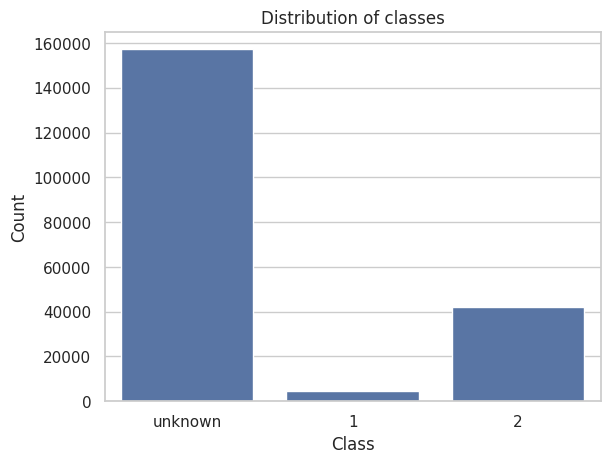

In [11]:
import seaborn as sns
import matplotlib.pyplot as plt
sns.set_theme(style="whitegrid")

df_count = df_classes.groupBy("class").count().toPandas()

sns.barplot(x="class", y="count", data=df_count)
plt.title("Distribution of classes")
plt.xlabel("Class")
plt.ylabel("Count")
plt.show()

Si recordamos la descripción: "Cada paso de tiempo contiene un único componente conexo de transacciones que aparecieron en la blockchain con menos de tres horas de diferencia entre sí; no hay aristas que conecten los diferentes pasos de tiempo". Comprobaremos esto y exploraremos más a fondo la columna de la marca de tiempo (timestamp).

In [12]:
from graphframes import GraphFrame


g = GraphFrame(df_features, df_edges)
g.vertices.show()
g.edges.show()

Py4JJavaError: An error occurred while calling o2103.newInstance.
: java.lang.NoClassDefFoundError: scala/Serializable
	at java.base/java.lang.ClassLoader.defineClass1(Native Method)
	at java.base/java.lang.ClassLoader.defineClass(ClassLoader.java:1017)
	at java.base/java.security.SecureClassLoader.defineClass(SecureClassLoader.java:150)
	at java.base/java.net.URLClassLoader.defineClass(URLClassLoader.java:524)
	at java.base/java.net.URLClassLoader$1.run(URLClassLoader.java:427)
	at java.base/java.net.URLClassLoader$1.run(URLClassLoader.java:421)
	at java.base/java.security.AccessController.doPrivileged(AccessController.java:712)
	at java.base/java.net.URLClassLoader.findClass(URLClassLoader.java:420)
	at java.base/java.lang.ClassLoader.loadClass(ClassLoader.java:592)
	at java.base/java.lang.ClassLoader.loadClass(ClassLoader.java:525)
	at org.graphframes.GraphFramePythonAPI.<init>(GraphFramePythonAPI.scala:12)
	at java.base/jdk.internal.reflect.NativeConstructorAccessorImpl.newInstance

Es interesante explorar la distribución de las clases agrupadas por timestamp.

In [14]:
df_dist = df_features.join(df_classes, "txId", "inner")
df_dist = df_dist.filter(df_dist["class"] != "unknown")
df_dist = df_dist.groupBy(sql_f.col("timestamp")).\
    agg(sql_f.avg(sql_f.when(df_dist["class"] == 1, 1).otherwise(0)).alias("ratio_classes"))

df_dist.orderBy("timestamp").show()

+---------+--------------------+
|timestamp|       ratio_classes|
+---------+--------------------+
|        1|0.007918025151374011|
|        2| 0.01611459265890779|
|        3|0.008600469116497263|
|        4|0.020833333333333332|
|        5|0.004250797024442083|
|        6|0.010309278350515464|
|        7| 0.08478802992518704|
|        8| 0.05751072961373391|
|        9| 0.31876606683804626|
|       10|0.018518518518518517|
|       11|  0.1882183908045977|
|       12| 0.03162055335968379|
|       13| 0.35970333745364647|
|       14| 0.10311750599520383|
|       15| 0.23786407766990292|
|       16| 0.24150943396226415|
|       17|  0.1220715166461159|
|       18| 0.13367609254498714|
|       19| 0.10738255033557047|
|       20| 0.28888888888888886|
+---------+--------------------+
only showing top 20 rows


In [15]:
df_dist = df_dist.toPandas()

/home/administrador/.pyenv/versions/elliptic/lib/python3.12/site-packages/pyspark/sql/pandas/conversion.py:94: UserWarning: toPandas attempted Arrow optimization because 'spark.sql.execution.arrow.pyspark.enabled' is set to true; however, failed by the reason below:
  [PACKAGE_NOT_INSTALLED] PyArrow >= 15.0.0 must be installed; however, it was not found.
Attempting non-optimization as 'spark.sql.execution.arrow.pyspark.fallback.enabled' is set to true.
  warn(msg)


/tmp/ipykernel_210627/1012860741.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  g = sns.catplot(


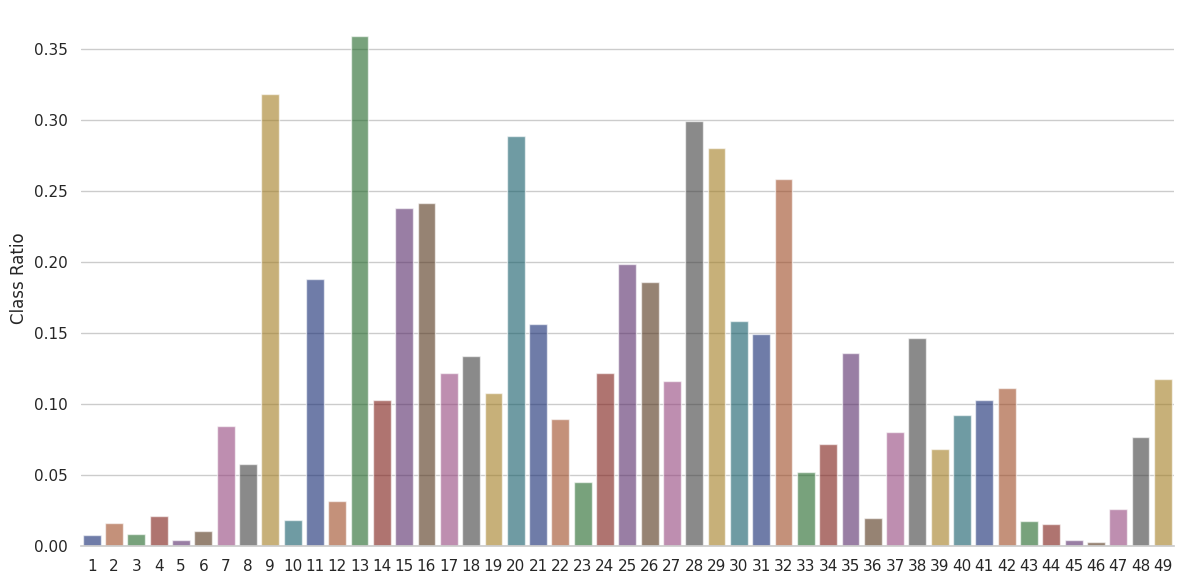

In [16]:
g = sns.catplot(
    data=df_dist, kind="bar",
    x="timestamp", y="ratio_classes",
    errorbar="sd", palette="dark", alpha=.6, height=6, 
    aspect=2
)
g.despine(left=True)
g.set_axis_labels("", "Class Ratio")

plt.tight_layout()
plt.show()

Como podemos ver, el desequilibrio es un problema para todas las marcas de tiempo.

## Entrenamiento del Modelo

No podemos entrenar basándonos únicamente en algoritmos tabulares, ya que también deseamos aprovechar la topología del grafo en sí. Un enfoque muy natural es utilizar GNNs (Redes Neuronales de Grafos), puesto que son capaces de agregar tanto la topología como las características de los nodos (y potencialmente de las aristas), de tal manera que un problema transductivo pueda resolverse eficazmente. Por otro lado, nos encontramos en un entorno distribuido. Implementar nuestro propio entrenamiento distribuido para un modelo de aprendizaje profundo (deep learning) podría resultar extremadamente desafiante. Spark ya ha implementado soluciones para esto, pero, con fines de aprendizaje, intentaremos implementar nuestros propios enfoques.

Una forma un tanto natural de utilizar GNNs en un entorno distribuido es entrenar un modelo en cada trabajador (worker) y, posteriormente, agregar el resultado de alguna manera. Existe una estructura interesante en torno a la propiedad de la marca de tiempo (timestamp), es decir, la naturaleza de los datos consiste en componentes de grafo disjuntos. Podríamos formular aquí una hipótesis: no existe ninguna preferencia sobre en qué momento temporal pueden ocurrir las transacciones lícitas o ilícitas y, por lo tanto, podría haber cierta invarianza temporal que podríamos explotar. En cualquier caso, podemos experimentar con la partición de los datos, aplicando ya sea esta estrategia de partición u otra basada en un muestreo más clásico con reemplazo. El aprendizaje federado (federated learning) es aquí la solución más natural. En particular, asumiendo I.I.D. (variables independientes e idénticamente distribuidas), lo cual es razonable de acuerdo con nuestra hipótesis, FedAVG debería funcionar bien.

### GNNs overview

There are several types of GNNs, but we will focus on Graph Convolutional Networks (GCNs). These models are convolutional in the sense that update each node by aggregating information from nearby nodes, and as such, they induce a relational inductive bias [1]. Each layer of the GCN can be described as a function $F[\bullet]$ with parameters $\Phi$ that takes the node embeddings and adjacency matrix and outputs new node embeddings:

$$H_1 = F[X, A, \Phi_0]$$
$$H_2 = F[H_1, A, \Phi_1]$$
$$\vdots$$
$$H_K = F[H_{K-1}, A, \Phi_{K-1}]$$

where $X$ is the input, $A$ the adjacency matrix, $H_k$ contains the modified node embeddings at the $k$-th layer, and $\Phi_k$ are the parameters associated with that layer. At the level of a single node, we have:

$$h_{k+1}^{(n)} = a[\beta_k + \Omega_k \cdot h_{k}^{(n)} + \Omega_k \cdot agg[n,k]]$$

where $a[\bullet]$ is the activation function, $\Omega_k$ is a linear transformation and $agg[\bullet]$ is an aggregation function on the neighborhood of the node, which could be just the sum of the neighbour embeddings. At the level of a whole layer, this can be written as:

$$H_{k+1} = a[\beta_k 1^T + \Omega_k H_{k} + \Omega_k H_k A] = a[\beta_k 1^T + \Omega_k H_{k} (A + I)]$$

In a more informal way, a GCN enriches the input embeddings of the graph nodes with information of their surroundings, outputting an enriched embedding for each node. This makes a GCN particularly suitable for transductive settings. In particular, for our purposes of node binary classification, the final layer should be of the following form:

$$f[X, A, \Phi] = sig[\beta_K 1^T + w_K H_K]$$

where $sig[\bullet]$ is a sigmoid function that gets applied independently to every element of the row vector input, necessary because we want to establish a probability distribution over the possible labels; since we are in a binary setting, we don't need a softmax. In other words, in the end we will have a predicted label $y^{(n)}$ for each node $n$ of the graph. The loss will then be a usual binary cross entropy, but with a couple of caveats:

- It will only be applied to the nodes for which we have a ground truth, meaning we will need to apply a mask. This shows why a GNN is so suitable for our purposes: the unlabeled nodes will simply be classified like any other node.
- Our classes are severely unbalanced. We can apply here other strategies, but the most simple one is modifying the loss function. We will try to apply weighting to penalize errors in the minority class [2].

The binary cross entropy loss function can be written as:

$$l(y, \hat{y}) = - (1 - y) \log(1 - \hat{y}) - y \log(\hat{y})$$

where $y \in \{1, -1\}$ is the ground truth label and $\hat{y} \in [0, 1]$ is the probability predicted by the model. The weighted cross entropy will just be:

$$l(y, \hat{y}) = - [\alpha \cdot (1 - y) \log(1 - \hat{y}) + \beta \cdot y \log(\hat{y})]$$

where $\alpha, \beta$ are hyperparameters, but they can be computed as:

$$\alpha = \frac{N}{2 \cdot \sum_{i=1}^{N} \mathbf{1}_{A}(y_i = -1)}$$
$$\beta = \frac{N}{2 \cdot \sum_{i=1}^{N} \mathbf{1}_{A}(y_i = 1)}$$

where $N$ is the dataset size.

### Implementation

First, we start with the implementation of the GCN. For that, we will be using PyTorch Geometric.

In [ ]:
import torch
import torch.nn.functional as F
from torch_geometric.nn import GCNConv


class GCN(torch.nn.Module):
    def __init__(self, in_channels, hidden_channels, out_channels):
        super().__init__()
        self._conv1 = GCNConv(in_channels, hidden_channels, normalize=False)
        self._conv2 = GCNConv(hidden_channels, out_channels, normalize=False)

    def forward(self, x, edge_index, edge_weight):
        x = F.dropout(x, p=0.5, training=self.training)
        x = self.conv1(x, edge_index, edge_weight).relu()
        x = F.dropout(x, p=0.5, training=self.training)
        x = self.conv2(x, edge_index)
        return x

We will need to send the training process to each worker. For this, we will define a Pandas UDF (code adapted from [4]).

In [ ]:
import numpy as np
from torch_geometric.data import Data


EPOCHS = 201

def train(model, optimizer, data, weights):
    model.train()
    optimizer.zero_grad()

    # The forward pass is done without any mask.
    out = model(data.x, data.edge_index, data.edge_weight).squeeze()

    # This loss function applies a sigmoid + weighted binary cross entropy.
    loss = torch.nn.BCEWithLogitsLoss(weight=weights)

    # The backward pass needs masking.
    output = loss(out[data.train_mask], data.y[data.train_mask].float())
    output.backward()
    optimizer.step()

    return float(output.detach())

@torch.no_grad
def test(model, data):
    model.eval()
    pred = model(data.x, data.edge_index, data.edge_weight).squeeze().argmax(dim=-1)

    accs = []
    for mask in [data.train_mask, data.val_mask, data.test_mask]:
        accs.append(int((pred[mask] == data.y[mask]).sum()) / int(mask.sum()))
    return accs

def draw_metrics(losses, train_accs, val_accs, test_accs):
    plt.figure(figsize=(12, 6))

    # Loss plot.
    plt.subplot(1, 2, 1)
    plt.plot(losses, label="Train Loss")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.title("Loss Evolution")
    plt.legend()

    # Accuracy plot.
    plt.subplot(1, 2, 2)
    plt.plot(train_accs, label="Train Accuracy")
    plt.plot(val_accs, label="Validation Accuracy")
    plt.plot(test_accs, label="Test Accuracy")
    plt.xlabel("Epoch")
    plt.ylabel("Accuracy")
    plt.title("Accuracy Evolution")
    plt.legend()

    plt.tight_layout()
    plt.show()

def train_local_gcn(pdf_iterator):
    # Spark returns the partition as an iterator with apache arrow.
    pdf = pd.concat(list(pdf_iterator))
    row = pdf.iloc[0]

    # Data tensors.
    x = torch.tensor(row['features'], dtype=torch.float)
    edge_index = torch.tensor(row['edge_index'], dtype=torch.long).t().contiguous()
    y = torch.tensor(row['class'], dtype=torch.long)
    num_nodes = x.size(0)

    # Calculates the weights for the weighted loss.
    w_0 = num_nodes / (2 * pdf.where(pdf["class"] == 1.0).values.sum())
    w_1 = num_nodes / (2 * pdf.where(pdf["class"] == 0.0).values.sum())
    weights = torch.tensor([w_0, w_1])

    # Masking
    known_mask = (y != -1.0)
    rand_tensor = torch.rand(num_nodes)
    train_mask = known_mask & (rand_tensor < 0.70)
    val_mask = known_mask & (rand_tensor >= 0.70) & (rand_tensor < 0.85)
    test_mask = known_mask & (rand_tensor >= 0.85)

    # PyG Data object that represents the graph.
    data = Data(
        x=x, 
        edge_index=edge_index, 
        y=y,
        train_mask=train_mask,
        val_mask=val_mask,
        test_mask=test_mask
    )

    model = GCN(
        in_channels=x.shape[1],
        hidden_channels=16,
        out_channels=2,
    ).to('cpu')

    optimizer = torch.optim.Adam([
        dict(params=model.conv1.parameters(), weight_decay=5e-4),
        dict(params=model.conv2.parameters(), weight_decay=0)
    ], lr=0.01)  # Only perform weight-decay on first convolution.

    # Lists for keeping the metrics.
    losses = []
    train_accs = []
    val_accs = []
    test_accs = []

    # Trains in full batch.
    for _ in range(1, EPOCHS):
        loss = train(model, optimizer, data, weights)
        train_acc, val_acc, test_acc = test(model, data)

        losses.append(loss); train_accs.append(train_acc)
        val_accs.append(val_acc); test_accs.append(test_acc)

    draw_metrics(losses, train_accs, val_accs, test_accs)
    state_dict = model.state_dict()

    dfs = []
    for layer_name, tensor in state_dict.items():
        # Flatten tensor to 1D vector.
        flat_array = tensor.cpu().detach().numpy().flatten()
        
        # Temporal dataframe for this layer with the indices.
        layer_df = pd.DataFrame({
            'layer_name': layer_name,
            'param_index': np.arange(len(flat_array)),
            'param_value': flat_array
        })
        dfs.append(layer_df)
        
    exploded_weights = pd.concat(dfs, ignore_index=True)
    exploded_weights['partition_id'] = row['partition_id']
    exploded_weights['n_samples'] = num_nodes 
    
    yield exploded_weights

We will now implement the main Spark process. We will investigate two alternatives, as we have discussed: partitioning the data via the timestamp or via usual random sampling. We need to also implement the federated learning procedure itself.

In [ ]:
def random_partition(df_nodes):
    # Random partitioning according to the threads available.
    cpu_threads = spark.sparkContext.defaultParallelism
    df_nodes = df_nodes.repartition(cpu_threads)
    df_nodes = df_nodes.withColumn(sql_f.spark_partition_id().alias("partition_id"))

    return df_nodes

def timestamp_partition(df_nodes):
    # Partitioning by timestamp, limiting by threads available.
    cpu_threads = spark.sparkContext.defaultParallelism
    df_nodes = df_nodes.repartition(cpu_threads, "timestamp")
    df_nodes = df_nodes.withColumn(sql_f.spark_partition_id().alias("partition_id"))

    return df_nodes

In [ ]:
from pyspark.ml.feature import VectorAssembler, MinMaxScaler
from pyspark.ml import Pipeline
from pyspark.ml.functions import vector_to_array


def preprocess_data(df_features, df_classes, df_edges, partition="random"):
    # Normalization.
    float_cols = [field[0] for field in df_features.dtypes if field[1] in ('float', 'double')]
    assembler = VectorAssembler(inputCols=float_cols, outputCol="features_vector")
    scaler = MinMaxScaler(inputCol="features_vector", outputCol="scaled_vector")
    pipeline = Pipeline(stages=[assembler, scaler])
    model = pipeline.fit(df_features)
    df_features = model.transform(df_features)
    df_features = df_features.withColumn("scaled_array", vector_to_array("scaled_vector"))
    for i, col_name in enumerate(float_cols):
        df_features = df_features.withColumn(col_name, F.col("scaled_array").getItem(i))
    df_features = df_features.drop("features_vector", "scaled_vector", "scaled_array")

    # Collects all the features as arrays in a single column "features".
    df_features = df_features.withColumn("features", sql_f.array(*float_cols))
    df_features = df_features.drop(*float_cols)

    # Processing of the class dataframe
    df_classes = df_classes.withColumn(
        "class",
        sql_f.when(sql_f.col("class") == "1", 1.0)
        .when(sql_f.col("class") == "2", 0.0)
        .otherwise(-1.0)
    )

    # Join of the features dataframe with the classes.
    df_nodes = df_features.join(df_classes, "txId")

    # Partition strategy.
    if partition == "random":
        df_nodes = random_partition(df_nodes)
    else:
        df_nodes = timestamp_partition(df_nodes)

    # Obtains the partition_id of the node 1, joinning the edge
    # and node dataframes so that each row is an edge.
    df_edges = df_edges.join(
        df_nodes.select(sql_f.col("txId").alias("txId1"), sql_f.col("partition_id").alias("partition_id_1")),
        on="txId1", how="inner"
    )

    # Obtains the partition_id of the second node and filter cutted edges.
    df_edges = df_edges.join(
        df_nodes.select(sql_f.col("txId").alias("txId2"), sql_f.col("partition_id").alias("partition_id_2")),
        on="txId2", how="inner"
    ).filter(sql_f.col("partition_id_1") == sql_f.col("partition_id_2")) \
    .drop("partition_id_2").withColumnRenamed("partition_id_1", "partition_id")

    # Groups nodes by partition_id and collects columns into lists.
    df_nodes_agg = df_nodes.groupBy("partition_id").agg(
        sql_f.collect_list("txId").alias("txId"),
        sql_f.collect_list("features").alias("features"),
        sql_f.collect_list("class").alias("class")
    )

    # Groups edges by partition_id.
    df_edges_agg = df_edges.withColumn("edge_pair", sql_f.array("txId1", "txId2")) \
        .groupBy("partition_id").agg(
            sql_f.collect_list("edge_pair").alias("edge_pair")
        )

    df_data = df_nodes_agg.join(df_edges_agg, on="partition_id", how="left")
    return df_data

In [ ]:
from pyspark.sql.types import *


def federated_avg(df_param):
    total_samples = df_param.select(sql_f.sum("n_samples")).first()[0]

    # FedAVG, weighted average per individual parameter.
    df_avg = df_param.withColumn(
        "weighted_val", 
        sql_f.col("param_value") * (sql_f.col("n_samples") / total_samples)
    ).groupBy("layer_name", "param_index").agg(
        sql_f.sum("weighted_val").alias("avg_param_value")
    )

    # Array reconstruction, we need to recover the original order. 
    # Groups by layer and then orders by index.
    df_global = df_avg.withColumn(
        "indexed_val", sql_f.struct("param_index", "avg_param_value")
    ).groupBy("layer_name").agg(
        sql_f.array_sort(sql_f.collect_list("indexed_val")).alias("sorted_params")
    ).select(
        "layer_name",
        # Discards the index.
        sql_f.transform("sorted_params", lambda x: x.avg_param_value).alias("flat_weights")
    )

    return df_global

In [ ]:
@torch.no_grad
def test_global(model, df_test):
    # Data tensors.
    x = torch.tensor(df_test['features'], dtype=torch.float)
    edge_index = torch.tensor(df_test['edge_index'], dtype=torch.long).t().contiguous()
    y = torch.tensor(r['class'], dtype=torch.long)
    num_nodes = x.size(0)

    # Calculates the weights for the weighted loss.
    w_0 = num_nodes / (2 * pdf.where(pdf["class"] == 1.0).values.sum())
    w_1 = num_nodes / (2 * pdf.where(pdf["class"] == 0.0).values.sum())
    weights = torch.tensor([w_0, w_1])

    # Masking
    known_mask = (y != -1.0)
    rand_tensor = torch.rand(num_nodes)
    train_mask = known_mask & (rand_tensor < 0.70)
    val_mask = known_mask & (rand_tensor >= 0.70) & (rand_tensor < 0.85)
    test_mask = known_mask & (rand_tensor >= 0.85)

    # PyG Data object that represents the graph.
    data = Data(
        x=x, 
        edge_index=edge_index, 
        y=y,
        train_mask=train_mask,
        val_mask=val_mask,
        test_mask=test_mask
    )

    model.eval()
    pred = model(data.x, data.edge_index, data.edge_weight).squeeze().argmax(dim=-1)

    accs = []
    for mask in [data.train_mask, data.val_mask, data.test_mask]:
        accs.append(int((pred[mask] == data.y[mask]).sum()) / int(mask.sum()))
    return accs

In [ ]:
import random


num_features = len(df_features.columns) - 1
df_data = preprocess_data(df_features, df_classes, df_edges, partition="timestamp")

# Holdout splitting by timestamp for training and evaluation
test_timestamps = random.choices(range(1, 50), k=3)
df_train = df_data.filter(sql_f.col("features")[1] in test_timestamps)
df_test = df_data.filter(sql_f.col("features")[1] not in test_timestamps)

schema = StructType([
    StructField("partition_id", LongType(), True),
    StructField("layer_name", StringType(), True),
    StructField("param_value", LongType(), True),
])

df_param = df_train.groupby("partition_id").mapInPandas(train_local_gcn, schema=schema)
df_global = federated_avg(df_param)

In [ ]:
global_weights = df_global.collect()
global_weights_dict = {row['layer_name']: row['flat_weights'] for row in global_weights}

global_model = GCN(
    in_channels=num_features,
    hidden_channels=16,
    out_channels=2,
).to('cpu')

original_state_dict = global_model.state_dict()

global_state_dict = {}
for layer_name, flat_weights in global_weights_dict.items():
    expected_shape = original_state_dict[layer_name].shape
    orig_tensor = torch.tensor(flat_weights).reshape(expected_shape)
    global_state_dict[layer_name] = orig_tensor

global_model.load_state_dict(global_state_dict)

## References

- [4] pyg-team. (s.f.). gcn.py [Source code]. GitHub. Recovered april 18th 2026, from https://github.com/pyg-team/pytorch_geometric/blob/master/examples/compile/gcn.py